# ENSO Prediction: EDA on Spatial Coverage and Data Quality

## Objective
Before modeling, we characterize where the tropical Pacific buoys are, how complete their data is, whether missing values are random or structured, and whether El Niño / La Niña classes behave differently by longitude. The results inform imputation, feature choices, and validation design.

## Contents
1. Setup and data loading
2. First Looks and Structural integrity checks
3. Spatial coverage
4. Missingness across space and time
5. Class behavior by longitude
6. Mean SSTA by longitude and year
7. Summary, modeling implications, and limitations

## 1. Setup and data loading
**What this does:** Reads the train and val feature files and stacks them into one DataFrame, with a `split` column to separate them later. `core` lists the five raw measurements used in the missing-data checks.

In [2]:
import os
import numpy as np
import pandas as pd

df = pd.concat(
    [pd.read_csv('../data/processed/features-train.csv').assign(split='train'),
     pd.read_csv('../data/processed/features-val.csv').assign(split='val')],
    ignore_index=True,
)
core = ['ssta','zonal_wind_anom','mer_wind_anom','air_temp_anom','humidity']


## 2. First Looks and Structural integrity checks
**What this does:** Reports split sizes and date ranges, NaN counts for every column, duplicate (buoy, month) rows, distinct locations per buoy, summary statistics, and the data folder layout.


In [3]:
print(df.shape, df['split'].value_counts().to_dict())
print(df.groupby('split')['ym'].agg(['min', 'max']))
print(df.isna().sum()[lambda s: s > 0])
print('duplicate (site, ym):', df.duplicated(['site_id', 'ym']).sum())
print('buoys:', df['site_id'].nunique(),
      '| max distinct lat/lon per buoy:', df.groupby('site_id')[['lat', 'lon']].nunique().max().tolist())
print(df.describe().T[['count', 'mean', 'std', 'min', 'max']])
for root, _, files in os.walk('../data'):
    print(root, files)

(3517, 43) {'train': 1988, 'val': 1529}
           min      max
split                  
train  1980-08  1993-09
val    1994-01  1996-09
humidity                 410
ssta_change1             182
ssta_change3             470
ssta_lag1                182
ssta_lag2                345
ssta_lag3                470
ssta_lag6                672
zonal_wind_anom_lag1     182
zonal_wind_anom_lag2     345
zonal_wind_anom_lag3     470
zonal_wind_anom_lag6     672
mer_wind_anom_lag1       182
mer_wind_anom_lag2       345
mer_wind_anom_lag3       470
mer_wind_anom_lag6       672
air_temp_anom_lag1       182
air_temp_anom_lag2       345
air_temp_anom_lag3       470
air_temp_anom_lag6       672
ssta_roll3               161
ssta_roll6                84
zonal_wind_anom_roll3    161
zonal_wind_anom_roll6     84
nino34_ssta_roll3         44
nino34_ssta               42
dtype: int64
duplicate (site, ym): 0
buoys: 62 | max distinct lat/lon per buoy: [1, 1]
                        count         mean         s

### Findings
- 3,517 rows x 43 columns. Train: 1,988 rows (1980-08 to 1993-09). Val: 1,529 rows (1994-01 to 1996-09).
- The split is chronological, and Oct to Dec 1993 is skipped, consistent with the 3-month prediction horizon.
- 62 buoys, each with a single lat/lon, and no duplicate (buoy, month) rows.
- NaNs extend beyond humidity: lag features (for example `ssta_lag1` 182, `ssta_lag3` 470, `ssta_lag6` 672), `ssta_change1` / `ssta_change3`, rolling means (`ssta_roll3` 161, `ssta_roll6` 84), and the Niño 3.4 features (`nino34_ssta` 42, `nino34_ssta_roll3` 44).
- The data is neither scaled nor imputed: humidity is in raw percent (about 69 to 96) and NaNs remain.
- `data/raw` holds the original TAO files, and `data/processed` holds `tao-all2*`, `elnino*`, and `features-*` CSVs.

## 3. Spatial coverage: where are the buoys, and when do they start reporting?
**What this does:** Converts longitude to 0 to 360 (`lon360`), builds one summary row per buoy (location, observation count, first and last date, months spanned, whether it appears in train), and maps the buoys. Marker size = observation count, color = first observation year, triangle = buoy that appears only in val.

**Why it matters:** Uneven coverage limits what the model can learn in each region, and any longitude analysis depends on knowing which buoys exist and when they begin.

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import chi2_contingency


df['date'] = pd.to_datetime(df['ym'])
df['lon360'] = df['lon'] % 360

buoys = (df.groupby('site_id')
    .agg(lat=('lat', 'first'), lon=('lon360', 'first'),
         n_obs=('date', 'size'), first=('date', 'min'), last=('date', 'max'),
         in_train=('split', lambda s: (s == 'train').any())))
buoys['span_months'] = ((buoys['last'] - buoys['first']).dt.days / 30.44).round() + 1
buoys['coverage'] = buoys['n_obs'] / buoys['span_months']
order = buoys.sort_values(['lon', 'lat']).index  

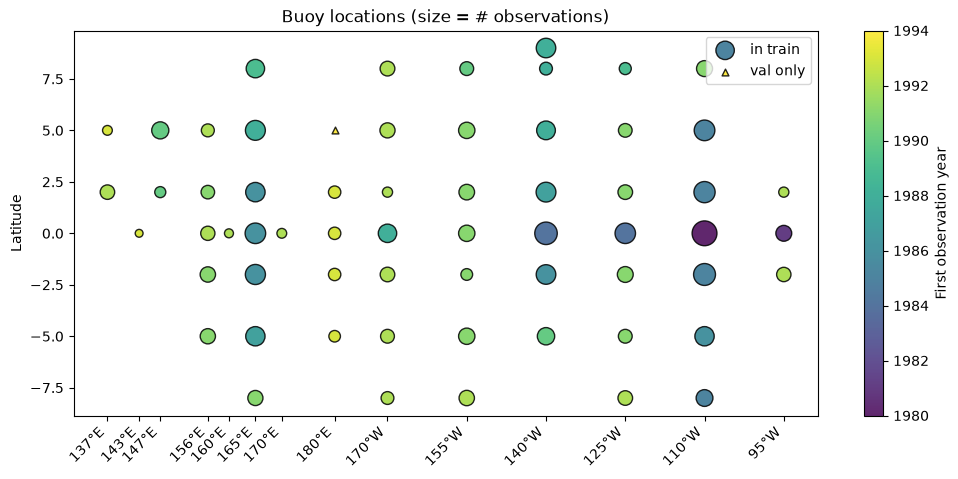

In [5]:
xt = sorted(buoys['lon'].unique())
fig, ax = plt.subplots(figsize=(12, 5))
buoys['first_year'] = buoys['first'].dt.year
for flag, marker, name in [(True, 'o', 'in train'), (False, '^', 'val only')]:
    b = buoys[buoys['in_train'] == flag]
    sc = ax.scatter(b['lon'], b['lat'], s=20 + 300 * b['n_obs'] / buoys['n_obs'].max(),
                    c=b['first_year'], cmap='viridis',
                    vmin=buoys['first_year'].min(), vmax=buoys['first_year'].max(),
                    marker=marker, edgecolor='k', alpha=0.85, label=name)
fig.colorbar(sc, ax=ax, label='First observation year')
ax.set_xticks(xt)
ax.set_xticklabels([f"{int(l)}°E" if l <= 180 else f"{int(360 - l)}°W" for l in xt], rotation=45, ha='right')
ax.set(ylabel='Latitude', title='Buoy locations (size = # observations)')
ax.legend(); plt.show()

### Findings
- 62 buoys on 14 meridians, densest near the equator. Only one buoy (5°N, 180°) is val-only, so train and val share nearly the same buoy set.
- The earliest records are equatorial buoys at 110°W and 95°W (1980 to 81), followed by the equatorial 140°W and 125°W buoys (about 1984), then 165°E and 170°W (about 1985 to 87). Most central and western buoys first appear between about 1989 and 1994.
- The largest observation counts are equatorial buoys in the east. Western buoys (137 to 160°E) have small counts.

## 4. Missingness across space and time
**What this does:** Draws heatmaps with one row per buoy (west to east) and one column per month for `humidity` (the only raw variable with NaNs) and `ssta_lag6` (the most-missing lag feature). The red line marks the start of val.

**Why it matters:** Whether missingness is random or structured determines whether, and how, it can be imputed.

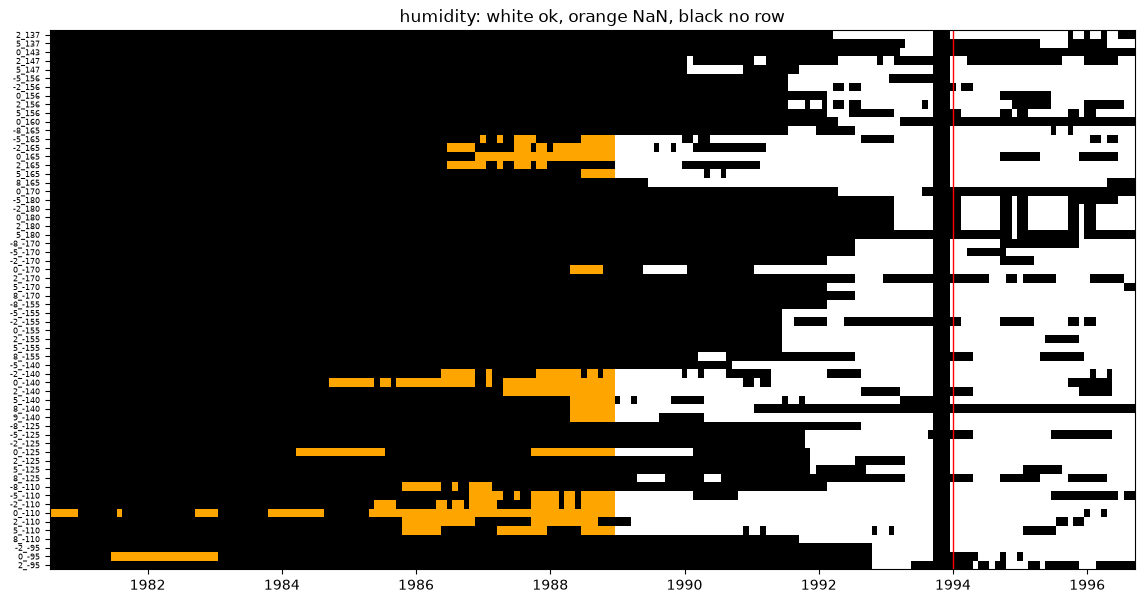

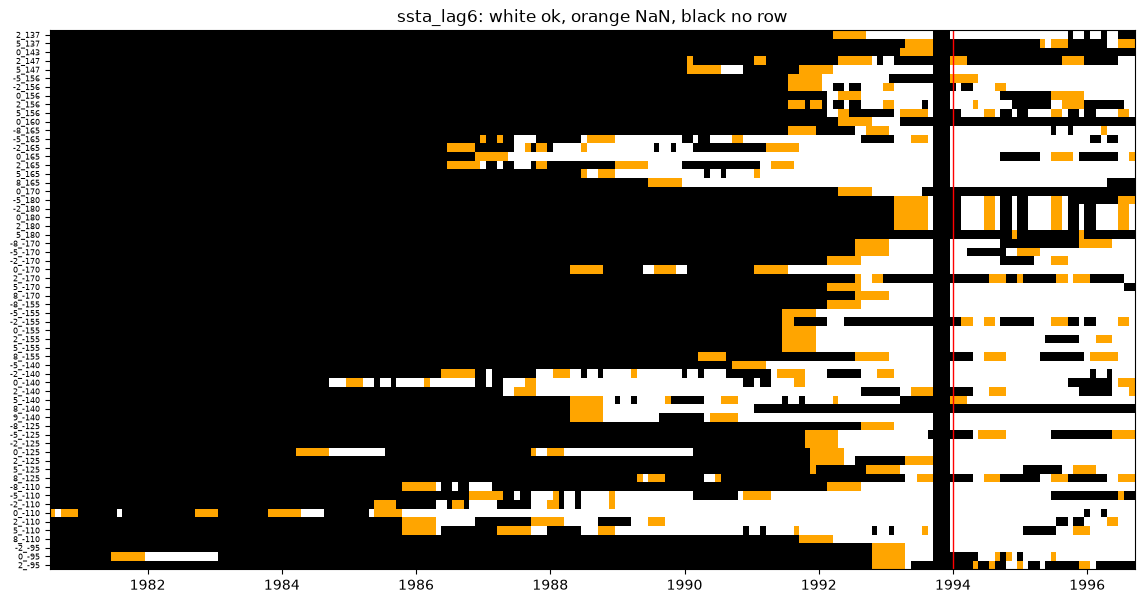

,buoys,rows,humidity_nan,lag6_nan
lon360,,,,
137.0,2,60,0.00,0.30
143.0,1,6,0.00,1.00
147.0,2,89,0.00,0.31
156.0,5,218,0.00,0.26
160.0,1,11,0.00,0.55
165.0,7,597,0.13,0.13
170.0,1,15,0.00,0.40
180.0,5,117,0.00,0.44
190.0,7,312,0.02,0.23


In [6]:
months = pd.date_range(df['date'].min(), df['date'].max(), freq='MS')
present = (df.pivot(index='site_id', columns='date', values='ssta')
             .reindex(index=order, columns=months).notna())
cmap = ListedColormap(['white', 'orange', 'black'])
cut = months.get_loc(pd.Timestamp('1994-01-01'))
yrs = [i for i, m in enumerate(months) if m.month == 1 and m.year % 2 == 0]

for col in ['humidity', 'ssta_lag6']:
    val = df.pivot(index='site_id', columns='date', values=col).reindex(index=order, columns=months)
    state = np.where(~present, 2, np.where(val.isna(), 1, 0))   # 0 ok, 1 NaN, 2 no row
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(state, aspect='auto', cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
    ax.axvline(cut, color='red', lw=1)
    ax.set_xticks(yrs); ax.set_xticklabels([months[i].year for i in yrs])
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=6)
    ax.set_title(f'{col}: white ok, orange NaN, black no row')
    plt.show()

(df.groupby('lon360')
   .agg(buoys=('site_id', 'nunique'), rows=('date', 'size'),
        humidity_nan=('humidity', lambda s: s.isna().mean()),
        lag6_nan=('ssta_lag6', lambda s: s.isna().mean()))
   .round(2))

### Findings
- **`ssta_lag6` NaNs appear at the start of each buoy's record and in roughly six-month shadows after gaps.** They are a consequence of missing months, not independent missingness.
- Large black areas are months with no row at all. Early coverage is thin, and later coverage is gappy. At 180° the gaps line up across buoys, which suggests a shared cause such as an outage or servicing (hypothesis).

## 5. Do El Niño / La Niña classes behave differently by longitude?
**What this does:** For each split, cross-tabulates `target_risk` by longitude, runs a chi-square test of independence with Cramér's V as the effect size, and plots class shares per longitude. Each bar is labeled with n, and bars with n < 30 are hatched. A final table gives the count, mean, and SD of `ssta` by split and longitude.

**Why it matters:** If class frequencies vary by longitude, location carries information. It also creates a risk that the model learns region-specific class priors that do not hold across time periods.

train chi2 p=9.22e-42, Cramer V=0.20
target_risk  Extreme Cool  Moderate Cool  Neutral  Moderate Warm  \
lon360                                                             
137.0                   0              0       23              0   
143.0                   0              0        6              0   
147.0                   0              0       46              0   
156.0                   0              0       89              0   
160.0                   0              0       11              0   
165.0                   5             42      296             48   
170.0                   0              0       15              0   
180.0                   0              0       28              0   
190.0                   5              4      103             16   
205.0                   0             22      109             19   
220.0                  37             70      183             90   
235.0                   9             23      106             20   
250.0      

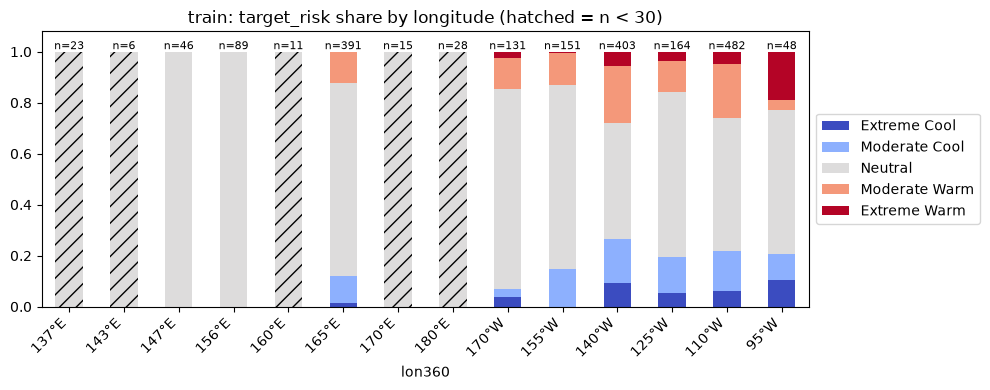

val chi2 p=2.29e-100, Cramer V=0.31
target_risk  Extreme Cool  Moderate Cool  Neutral  Moderate Warm  \
lon360                                                             
137.0                   0              0       19             18   
147.0                   0              0       23             20   
156.0                   0              2       58             62   
165.0                   0             10      148             48   
180.0                  16             37       32              4   
190.0                  15             69       79             14   
205.0                  17             87       86             11   
220.0                  10             48       99             18   
235.0                  16             72       91             10   
250.0                   5             63      110             26   
265.0                  31             20       12              6   

target_risk  Extreme Warm    n  
lon360                          
137.0        

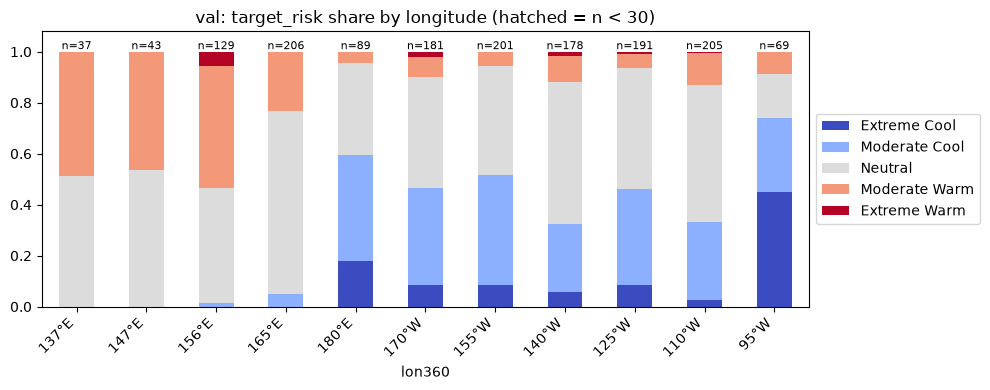

              count  mean   std
split lon360                   
train 137.0      23 -0.01  0.25
      143.0       6 -0.12  0.13
      147.0      46 -0.01  0.24
      156.0      89  0.03  0.26
      160.0      11  0.02  0.05
      165.0     391 -0.03  0.51
      170.0      15  0.02  0.09
      180.0      28 -0.00  0.00
      190.0     131  0.02  0.58
      205.0     151  0.03  0.54
      220.0     403 -0.03  1.05
      235.0     164 -0.07  0.95
      250.0     482 -0.01  1.00
      265.0      48 -0.13  1.21
val   137.0      37  0.47  0.43
      147.0      43  0.37  0.39
      156.0     129  0.58  0.47
      165.0     206  0.22  0.42
      180.0      89 -0.62  0.73
      190.0     181 -0.38  0.80
      205.0     201 -0.60  0.76
      220.0     178 -0.12  0.66
      235.0     191 -0.48  0.76
      250.0     205 -0.20  0.63
      265.0      69 -1.08  1.25


In [7]:
classes = ['Extreme Cool', 'Moderate Cool', 'Neutral', 'Moderate Warm', 'Extreme Warm']
for name, d in df.groupby('split'):
    ct = pd.crosstab(d['lon360'], d['target_risk']).reindex(columns=classes, fill_value=0)
    chi2, p, dof, _ = chi2_contingency(ct.loc[:, ct.sum() > 0])
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    print(name, f'chi2 p={p:.3g}, Cramer V={v:.2f}')
    print(ct.assign(n=ct.sum(axis=1)))
    n = ct.sum(axis=1)
    MIN_N = 30                                   # bars with fewer rows than this get hatched
    lab = [f"{int(l)}°E" if l <= 180 else f"{int(360 - l)}°W" for l in ct.index]

    ax = ct.div(n, axis=0).plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(10, 4),
                                title=f'{name}: target_risk share by longitude (hatched = n < {MIN_N})')
    ax.set_xticklabels(lab, rotation=45, ha='right')
    ax.set_ylim(0, 1.08)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    L = len(ct)
    for i in range(L):
        ax.text(i, 1.01, f"n={n.iloc[i]}", ha='center', fontsize=8)
        if n.iloc[i] < MIN_N:
            for k in range(len(ct.columns)):
                ax.patches[k * L + i].set_hatch('//')
    plt.tight_layout(); plt.show()

print(df.groupby(['split', 'lon360'])['ssta'].agg(['count', 'mean', 'std']).round(2))

### Findings
- **Longitude and class are associated in both splits** (Cramér's V = 0.20 in train, 0.31 in val). The p-values are extremely small but overstated, because neighboring months and buoys are strongly correlated. Rely on V and the plots.
- **Class balance differs by split** (computed from the crosstabs). Train: Neutral 65%, Moderate Cool 12%, Moderate Warm 15%, Extreme Cool 4.5%, Extreme Warm 3.3%. Val: Neutral 50%, Moderate Cool 27%, Moderate Warm 16%, Extreme Cool 7%, Extreme Warm 1.1%.
- **Train:** Western longitudes (137 to 160°E, 170°E, 180°) are 100% Neutral. Several of these bars have few rows (hatched), but 147°E (n=46) and 156°E (n=89) are also entirely Neutral. Extreme classes are mainly east of 170°W. At 95°W, 9 of 48 rows are Extreme Warm and 5 are Extreme Cool, which is a small sample.
- **Val:** The pattern flips. From 180° eastward, between a third (140°W and 110°W) and three-quarters (95°W, n=69) of rows are cool classes. The far west (137 to 156°E) is about 50% warm. This is consistent with a west-warm, east-cool see-saw.
- **Variability increases from west to east in both splits.** SSTA SD in train is about 0.25 at 137 to 156°E, about 0.5 at 165°E to 155°W, and about 1.0 from 140°W to 95°W. In val it is about 0.4 to 0.5 in the west and 0.6 to 1.25 farther east. Because the class cut-offs are fixed in °C, western buoys rarely leave Neutral.
- Mean SSTA is near 0 at every longitude in train (about -0.13 to +0.03) but strongly shifted in val (+0.2 to +0.6 in the west, -0.1 to -1.1 in the east). The class mix at a given longitude reflects which ENSO phase the period contained.

## 6. Mean SSTA by longitude and year
**What this does:** Pivots mean `ssta` by longitude x year, blanks cells with fewer than 5 rows, and uses a diverging colormap centered on zero (red = warm, blue = cool). The black line marks the start of val.

**Why it matters:** It separates a location effect from a time (ENSO event) effect, which the class bars alone cannot do.

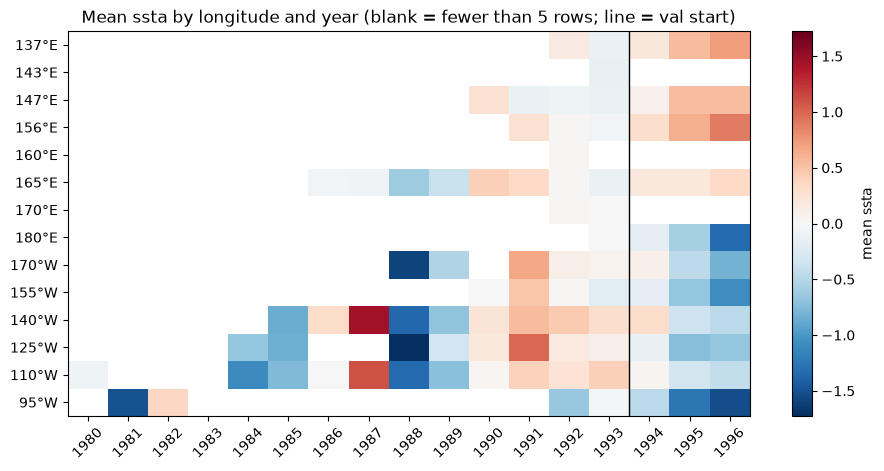

In [8]:
piv = df.pivot_table(index='lon360', columns='year', values='ssta', aggfunc='mean')
cnt = df.pivot_table(index='lon360', columns='year', values='ssta', aggfunc='size')
piv = piv.where(cnt >= 5)                    # blank out cells with fewer than 5 rows
lim = np.nanmax(np.abs(piv.values))

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(piv, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim, interpolation='nearest')
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=45)
ax.set_yticks(range(piv.shape[0]))
ax.set_yticklabels([f"{int(l)}°E" if l <= 180 else f"{int(360 - l)}°W" for l in piv.index])
ax.axvline(list(piv.columns).index(1994) - 0.5, color='k', lw=1)    # val starts
fig.colorbar(im, ax=ax, label='mean ssta')
ax.set_title('Mean ssta by longitude and year (blank = fewer than 5 rows; line = val start)')
plt.show()

### Findings
- Known events show up as vertical bands: warm in the east in 1987 (about +1.5 at 140°W), cool in 1988 (down to about -1.7 at 125°W), and warm in 1991.
- In 1995 to 1996 the west is warm (about +0.5 to +0.9 at 137 to 156°E) while 180° and the east are cool (about -1.5 by 1996 at 180° and 95°W). This is the see-saw seen in the val bar chart.
- 1983 is blank at every longitude, so the peak of the 1982-83 El Niño is not observed as current SSTA. Before about 1990, coverage is limited to the eastern buoys and 165°E.
- Longitude differences in class mix therefore largely reflect which ENSO phase each longitude was sampled in.

## 7. Summary

| Finding | Implication for modeling |
|---|---|
| Lag and rolling NaNs follow gaps | Treat as structural. Use NaN-tolerant models or interpolate short gaps only. Avoid mean fill |
| Val is essentially one cool-phase window | Use blocked, forward-chaining validation with gaps at least as long as the lag window (6 months). Report results per event or phase |
| Class mix by longitude is unstable over time, while variability by longitude is stable | Test with and without `lat`/`lon`, since location may mostly proxy for typical variability. Report per-region metrics |
| Coverage is uneven over time | Be cautious about extrapolating from the early, east-only years. Report results by region |